# **서울시 주유소 가격 데이터 분석 프로젝트**

## **1. 프로젝트 Overview** 
- 데이터 분석 준비 
- 데이터 수집 (웹크롤링)
- 데이터 전처리 
- 데이터 분석
- 데이터 분석 결과

## **2. 데이터 확보하기 위한 작업** 
- https://www.opinet.co.kr/searRgSelect.do
- 웹 페이지 구조 확인
- 목표 데이터
    - 엑셀 데이터
        - 브랜드
        - 셀프 주유 여부
        - 주소
        - 가격 

## **3. 데이터 수집**
- selenium 
- https://selenium-python.readthedocs.io/getting-started.html

### **3-1. 필요한 도구 불러오기**

In [1]:
import time

# 데이터 분석 도구
import pandas as pd
import numpy as np

# 데이터 시각화 도구
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# 데이터 수집 도구
from selenium import webdriver
from selenium.webdriver.common.by import By

# 기타 도구
from glob import glob

### **3-2. 셀레니움으로 웹페이지 접근하기**

In [5]:
# 1. 웹페이지 접속
# 2. 서울시 선택 (고정)
# 3. 서울시 구 하나 선택
# 4. 서울시 구에 해당하는 엑셀 파일 다운로드
# 5. 서울시 모든 구 반복

In [6]:
# 1. 웹페이지 접속
url = 'https://www.opinet.co.kr/searRgSelect.do'
driver = webdriver.Chrome()
driver.get(url)

In [7]:
# 브라우저 크기 최대
driver.maximize_window()

In [8]:
# 지역: 시/도
sido_list_raw = driver.find_element(By.ID, 'SIDO_NM0')
sido_list_raw.text

'            시/도\n            \n             \n             \n              서울\n             \n            \n             \n             \n              부산\n             \n            \n             \n             \n              대구\n             \n            \n             \n             \n              인천\n             \n            \n             \n             \n              광주\n             \n            \n             \n             \n              대전\n             \n            \n             \n             \n              울산\n             \n            \n             \n             \n              세종\n             \n            \n             \n             \n              경기\n             \n            \n             \n             \n              강원\n             \n            \n             \n             \n              충북\n             \n            \n             \n             \n              충남\n             \n            \n             \n             \n              

In [9]:
# 시 단위 리스트 데이터 확인
sido_list = sido_list_raw.find_elements(By.TAG_NAME, 'option')
sido_list[2].text

'부산'

In [10]:
# option 태그가 가진 value 이름의 속성값 데이터 추출
sido_list[2].get_attribute('value')

'부산광역시'

In [11]:
# 시/도 리스트 데이터로 저장하기
sido_names = []

for option in sido_list:
    print(option.text)
    sido_names.append(option.get_attribute('value'))

시/도
서울
부산
대구
인천
광주
대전
울산
세종
경기
강원
충북
충남
전북
전남
경북
경남
제주


In [12]:
# 맨 앞 데이터가 빈 내용으로 나와서, 제거하고 다시 저장
sido_names = sido_names[1:]
sido_names

['서울특별시',
 '부산광역시',
 '대구광역시',
 '인천광역시',
 '광주광역시',
 '대전광역시',
 '울산광역시',
 '세종특별자치시',
 '경기도',
 '강원특별자치도',
 '충청북도',
 '충청남도',
 '전북특별자치도',
 '전라남도',
 '경상북도',
 '경상남도',
 '제주특별자치도']

In [13]:
sido_list_raw.send_keys(sido_names[0])

In [14]:
# 2. 서울시 데이터 리스트 확보
# 서울시 고정
sido_list_raw = driver.find_element(By.ID, 'SIDO_NM0')
sido_list = sido_list_raw.find_elements(By.TAG_NAME, 'option')

sido_names = []
for option in sido_list:
    print(option.text)
    sido_names.append(option.get_attribute('value'))

sido_names = sido_names[1:]
sido_list_raw.send_keys(sido_names[0])

시/도
서울
부산
대구
인천
광주
대전
울산
세종
경기
강원
충북
충남
전북
전남
경북
경남
제주


In [15]:
# 3. 구 단위 데이터 리스트로 저장
gu_list_raw = driver.find_element(By.ID, 'SIGUNGU_NM0')
gu_list = gu_list_raw.find_elements(By.TAG_NAME, 'option')

gu_names = []
for option in gu_list:
    gu_names.append(option.get_attribute('value'))

gu_names = gu_names[1:]
gu_names

['강남구',
 '강동구',
 '강북구',
 '강서구',
 '관악구',
 '광진구',
 '구로구',
 '금천구',
 '노원구',
 '도봉구',
 '동대문구',
 '동작구',
 '마포구',
 '서대문구',
 '서초구',
 '성동구',
 '성북구',
 '송파구',
 '양천구',
 '영등포구',
 '용산구',
 '은평구',
 '종로구',
 '중구',
 '중랑구']

In [ ]:
# 4. 엑셀 파일 다운로드
element_get_excel = driver.find_element(By.CLASS_NAME, 'btn_type6_ex_save')
element_get_excel.click()

In [22]:
for gu in gu_names:
    print(gu)

강남구
강동구
강북구
강서구
관악구
광진구
구로구
금천구
노원구
도봉구
동대문구
동작구
마포구
서대문구
서초구
성동구
성북구
송파구
양천구
영등포구
용산구
은평구
종로구
중구
중랑구


In [23]:
# 5. 모든 구에 반복해서 주유소 정보 엑셀 파일 다운로드

# 서울시 모든 구를 반복
for gu in gu_names:
    # try except 웹 크롤링 예상 오류 대비
    try:
        # 구 선택
        element = driver.find_element(By.ID, 'SIGUNGU_NM0')
        # 순서대로 구 정보 입력
        element.send_keys(gu)
        time.sleep(2) # 로딩이 될 때까지 잠시 대기

        # 그 구에 해당하는 엑셀 데이터 다운로드
        element_get_excel = driver.find_element(By.CLASS_NAME, 'btn_type6_ex_save')
        element_get_excel.click()
        time.sleep(2)
        print(f'{gu} 엑셀 데이터를 다운받았습니다!')
    except:
        print(f'{gu} 엑셀 데이터를 다운받지 못했습니다...')
        continue

강남구 엑셀 데이터를 다운받았습니다!
강동구 엑셀 데이터를 다운받았습니다!
강북구 엑셀 데이터를 다운받았습니다!
강서구 엑셀 데이터를 다운받았습니다!
관악구 엑셀 데이터를 다운받았습니다!
광진구 엑셀 데이터를 다운받았습니다!
구로구 엑셀 데이터를 다운받았습니다!
금천구 엑셀 데이터를 다운받았습니다!
노원구 엑셀 데이터를 다운받았습니다!
도봉구 엑셀 데이터를 다운받았습니다!
동대문구 엑셀 데이터를 다운받았습니다!
동작구 엑셀 데이터를 다운받았습니다!
마포구 엑셀 데이터를 다운받았습니다!
서대문구 엑셀 데이터를 다운받았습니다!
서초구 엑셀 데이터를 다운받았습니다!
성동구 엑셀 데이터를 다운받았습니다!
성북구 엑셀 데이터를 다운받았습니다!
송파구 엑셀 데이터를 다운받았습니다!
양천구 엑셀 데이터를 다운받았습니다!
영등포구 엑셀 데이터를 다운받았습니다!
용산구 엑셀 데이터를 다운받았습니다!
은평구 엑셀 데이터를 다운받았습니다!
종로구 엑셀 데이터를 다운받았습니다!
중구 엑셀 데이터를 다운받았습니다!
중랑구 엑셀 데이터를 다운받았습니다!


In [ ]:
# 작업이 끝났으면 드라이버 종료
driver.quit()

## **4. 데이터 정리하기**

### **4-1. 여러 개의 엑셀 파일 하나로 합치기**
- glob 
- 특정 패턴과 일치하는 파일명을 리스트로 반환

In [21]:
station_files = glob('./Data/*.xls')
len(station_files), station_files[:5]

(26,
 ['./Data\\지역_위치별(주유소) (1).xls',
  './Data\\지역_위치별(주유소) (10).xls',
  './Data\\지역_위치별(주유소) (11).xls',
  './Data\\지역_위치별(주유소) (12).xls',
  './Data\\지역_위치별(주유소) (13).xls'])

In [22]:
tmp = pd.read_excel(station_files[0], header=2)
tmp.tail(2)

,지역,상호,주소,상표,전화번호,셀프여부,고급휘발유,휘발유,경유,실내등유
11,서울특별시,천호현대주유소,서울 강동구 천중로 67 (천호동),HD현대오일뱅크,02-484-9323,N,-,2050,1945,-
12,서울특별시,광성주유소,서울 강동구 올림픽로 673 (천호동),S-OIL,02-470-5133,N,-,2118,2048,-


In [23]:
tmp_raw = []
for file_name in station_files:
    # 엑셀 파일을 Pandas 데이터프레임으로 저장
    tmp = pd.read_excel(file_name, header=2)
    # 데이터프레임을 리스트안에 저장
    tmp_raw.append(tmp)

In [24]:
len(tmp_raw)

26

In [25]:
tmp_raw[1].tail()

,지역,상호,주소,상표,전화번호,셀프여부,고급휘발유,휘발유,경유,실내등유
13,서울특별시,동서울고속주유소,서울 동대문구 한천로 414,SK에너지,02-969-1144,Y,1929,1839,1739,-
14,서울특별시,오동나무주유소,서울 동대문구 한천로 81 (답십리동),S-OIL,02-2247-5132,N,-,1848,1748,1500
15,서울특별시,삼미상사(주)장안킹셀프주유소,서울 동대문구 한천로 100 (장안동),SK에너지,02-2242-7115,Y,-,1878,1779,-
16,서울특별시,배봉로주유소,서울 동대문구 서울시립대로 108,HD현대오일뱅크,02-2242-0556,Y,-,1880,1818,-
17,서울특별시,홍능주유소,서울 동대문구 홍릉로 87 (청량리동),S-OIL,02-966-9190,N,-,-,-,-


In [26]:
stations_raw = pd.concat(tmp_raw)
stations_raw.head()

,지역,상호,주소,상표,전화번호,셀프여부,고급휘발유,휘발유,경유,실내등유
0,서울특별시,재건에너지 재정제2주유소 고속셀프지점,서울특별시 강동구 천호대로 1246 (둔촌제2동),HD현대오일뱅크,02-487-2030,Y,-,1809,1719,-
1,서울특별시,구천면주유소,서울 강동구 구천면로 357 (암사동),HD현대오일뱅크,02-441-0536,N,-,1824,1735,-
2,서울특별시,(주)소모 신월주유소,서울 강동구 양재대로 1323 (성내동),GS칼텍스,02-6956-6674,Y,2036,1846,1748,1590
3,서울특별시,대성석유(주)길동주유소,서울 강동구 천호대로 1168,GS칼텍스,02-474-7222,N,2045,1856,1758,1600
4,서울특별시,(주)삼표에너지 고덕주유소,서울 강동구 고덕로 39 (암사동),GS칼텍스,02-441-3327,Y,2065,1865,1765,1705


In [27]:
# 요약 정보 확인
# 전처리에 필요한 부분 확인
# 인덱스 번호와 기름의 가격 데이터 타입을 숫자로 수정
stations_raw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 450 entries, 0 to 33
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   지역      450 non-null    object
 1   상호      450 non-null    object
 2   주소      450 non-null    object
 3   상표      450 non-null    object
 4   전화번호    450 non-null    object
 5   셀프여부    450 non-null    object
 6   고급휘발유   450 non-null    object
 7   휘발유     450 non-null    object
 8   경유      450 non-null    object
 9   실내등유    450 non-null    object
dtypes: object(10)
memory usage: 38.7+ KB


### **4-2. 의미있는 데이터만 뽑아 사용하기**

In [28]:
stations_raw.head(1)

,지역,상호,주소,상표,전화번호,셀프여부,고급휘발유,휘발유,경유,실내등유
0,서울특별시,재건에너지 재정제2주유소 고속셀프지점,서울특별시 강동구 천호대로 1246 (둔촌제2동),HD현대오일뱅크,02-487-2030,Y,-,1809,1719,-


In [29]:
data = {
    '상호': stations_raw['상호'],
    '주소': stations_raw['주소'],
    '휘발유': stations_raw['휘발유'],
    '경유': stations_raw['경유'],
    '셀프': stations_raw['셀프여부'],
    '상표': stations_raw['상표']
}

In [30]:
# raw 데이터에서 의미있는 데이터만 뽑아서 사용하기
stations = pd.DataFrame(data)
stations.tail()

,상호,주소,휘발유,경유,셀프,상표
29,SK논현주유소,서울 강남구 논현로 747 (논현동),2440,2355,N,SK에너지
30,(주)제이제이네트웍스 제이제이주유소,서울 강남구 언주로 716,2560,2450,N,HD현대오일뱅크
31,(주)만정에너지 삼보주유소,서울 강남구 봉은사로 433 (삼성동),2598,2560,N,GS칼텍스
32,HD현대오일뱅크㈜직영 신사현대주유소,서울 강남구 도산대로 163 (신사동),-,-,N,HD현대오일뱅크
33,HD현대오일뱅크㈜직영 도곡셀프주유소,서울 강남구 남부순환로 2718 (도곡2동),-,-,Y,HD현대오일뱅크


In [31]:
# 구 컬럼 추가
text = '서울 동작구 상도로 403 (상도동)'
text.split()[1]

'동작구'

In [32]:
# 구 데이터를 리스트 형태로 저장
station_gu_list = []
for address in stations['주소']:
    gu = address.split()[1]
    station_gu_list.append(gu)
len(station_gu_list), len(stations)

(450, 450)

In [34]:
# 구 컬럼 추가
stations['구'] = station_gu_list
stations.head()

,상호,주소,휘발유,경유,셀프,상표,구
0,재건에너지 재정제2주유소 고속셀프지점,서울특별시 강동구 천호대로 1246 (둔촌제2동),1809,1719,Y,HD현대오일뱅크,강동구
1,구천면주유소,서울 강동구 구천면로 357 (암사동),1824,1735,N,HD현대오일뱅크,강동구
2,(주)소모 신월주유소,서울 강동구 양재대로 1323 (성내동),1846,1748,Y,GS칼텍스,강동구
3,대성석유(주)길동주유소,서울 강동구 천호대로 1168,1856,1758,N,GS칼텍스,강동구
4,(주)삼표에너지 고덕주유소,서울 강동구 고덕로 39 (암사동),1865,1765,Y,GS칼텍스,강동구


### **4-3. 가격 데이터 타입, 인덱스 재정렬**

In [35]:
# 가격 데이터 타입 변환
# object -> float
stations['휘발유'].astype(float)

ValueError: could not convert string to float: '-'

In [36]:
# 가격 정보 없는 주유소
stations[stations['휘발유'] == '-']

,상호,주소,휘발유,경유,셀프,상표,구
17,홍능주유소,서울 동대문구 홍릉로 87 (청량리동),-,-,N,S-OIL,동대문구
28,HD현대오일뱅크㈜직영 서초제일주유소,서울 서초구 사임당로 116 (서초동),-,-,N,HD현대오일뱅크,서초구
29,HD현대오일뱅크㈜직영 사평로주유소,서울 서초구 사평대로 350 (서초동),-,-,N,HD현대오일뱅크,서초구
15,HD현대오일뱅크㈜직영 성동셀프주유소,서울 성동구 마장로 311 (마장동),-,-,Y,HD현대오일뱅크,성동구
32,HD현대오일뱅크㈜직영 신사현대주유소,서울 강남구 도산대로 163 (신사동),-,-,N,HD현대오일뱅크,강남구
33,HD현대오일뱅크㈜직영 도곡셀프주유소,서울 강남구 남부순환로 2718 (도곡2동),-,-,Y,HD현대오일뱅크,강남구


In [37]:
# 가격 정보가 있는 주유소만 사용
stations = stations[stations['휘발유'] != '-']
stations = stations[stations['경유'] != '-']
stations.info()

<class 'pandas.core.frame.DataFrame'>
Index: 443 entries, 0 to 31
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   상호      443 non-null    object
 1   주소      443 non-null    object
 2   휘발유     443 non-null    object
 3   경유      443 non-null    object
 4   셀프      443 non-null    object
 5   상표      443 non-null    object
 6   구       443 non-null    object
dtypes: object(7)
memory usage: 27.7+ KB


In [38]:
stations['휘발유'] = stations['휘발유'].astype(float)
stations['경유'] = stations['경유'].astype(float)
stations.info()

<class 'pandas.core.frame.DataFrame'>
Index: 443 entries, 0 to 31
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   상호      443 non-null    object 
 1   주소      443 non-null    object 
 2   휘발유     443 non-null    float64
 3   경유      443 non-null    float64
 4   셀프      443 non-null    object 
 5   상표      443 non-null    object 
 6   구       443 non-null    object 
dtypes: float64(2), object(5)
memory usage: 27.7+ KB


In [39]:
# 인덱스 재정렬
stations.reset_index(drop=True, inplace=True)
stations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 443 entries, 0 to 442
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   상호      443 non-null    object 
 1   주소      443 non-null    object 
 2   휘발유     443 non-null    float64
 3   경유      443 non-null    float64
 4   셀프      443 non-null    object 
 5   상표      443 non-null    object 
 6   구       443 non-null    object 
dtypes: float64(2), object(5)
memory usage: 24.4+ KB


## **5. 데이터 분석** 
- 주유 가격 정보 시각화

### **5-1. 기본 그래프 사용 시각화**
- 박스플롯
- 가격에 대한 비교 
- 가격 분포에 대한 비교

In [40]:
stations[stations['휘발유'] > 2700]

,상호,주소,휘발유,경유,셀프,상표,구
232,서계주유소,서울 용산구 청파로 367 (청파동),2805.0,2795.0,N,GS칼텍스,용산구
266,서남주유소,서울 중구 통일로 30,2813.0,2777.0,N,SK에너지,중구


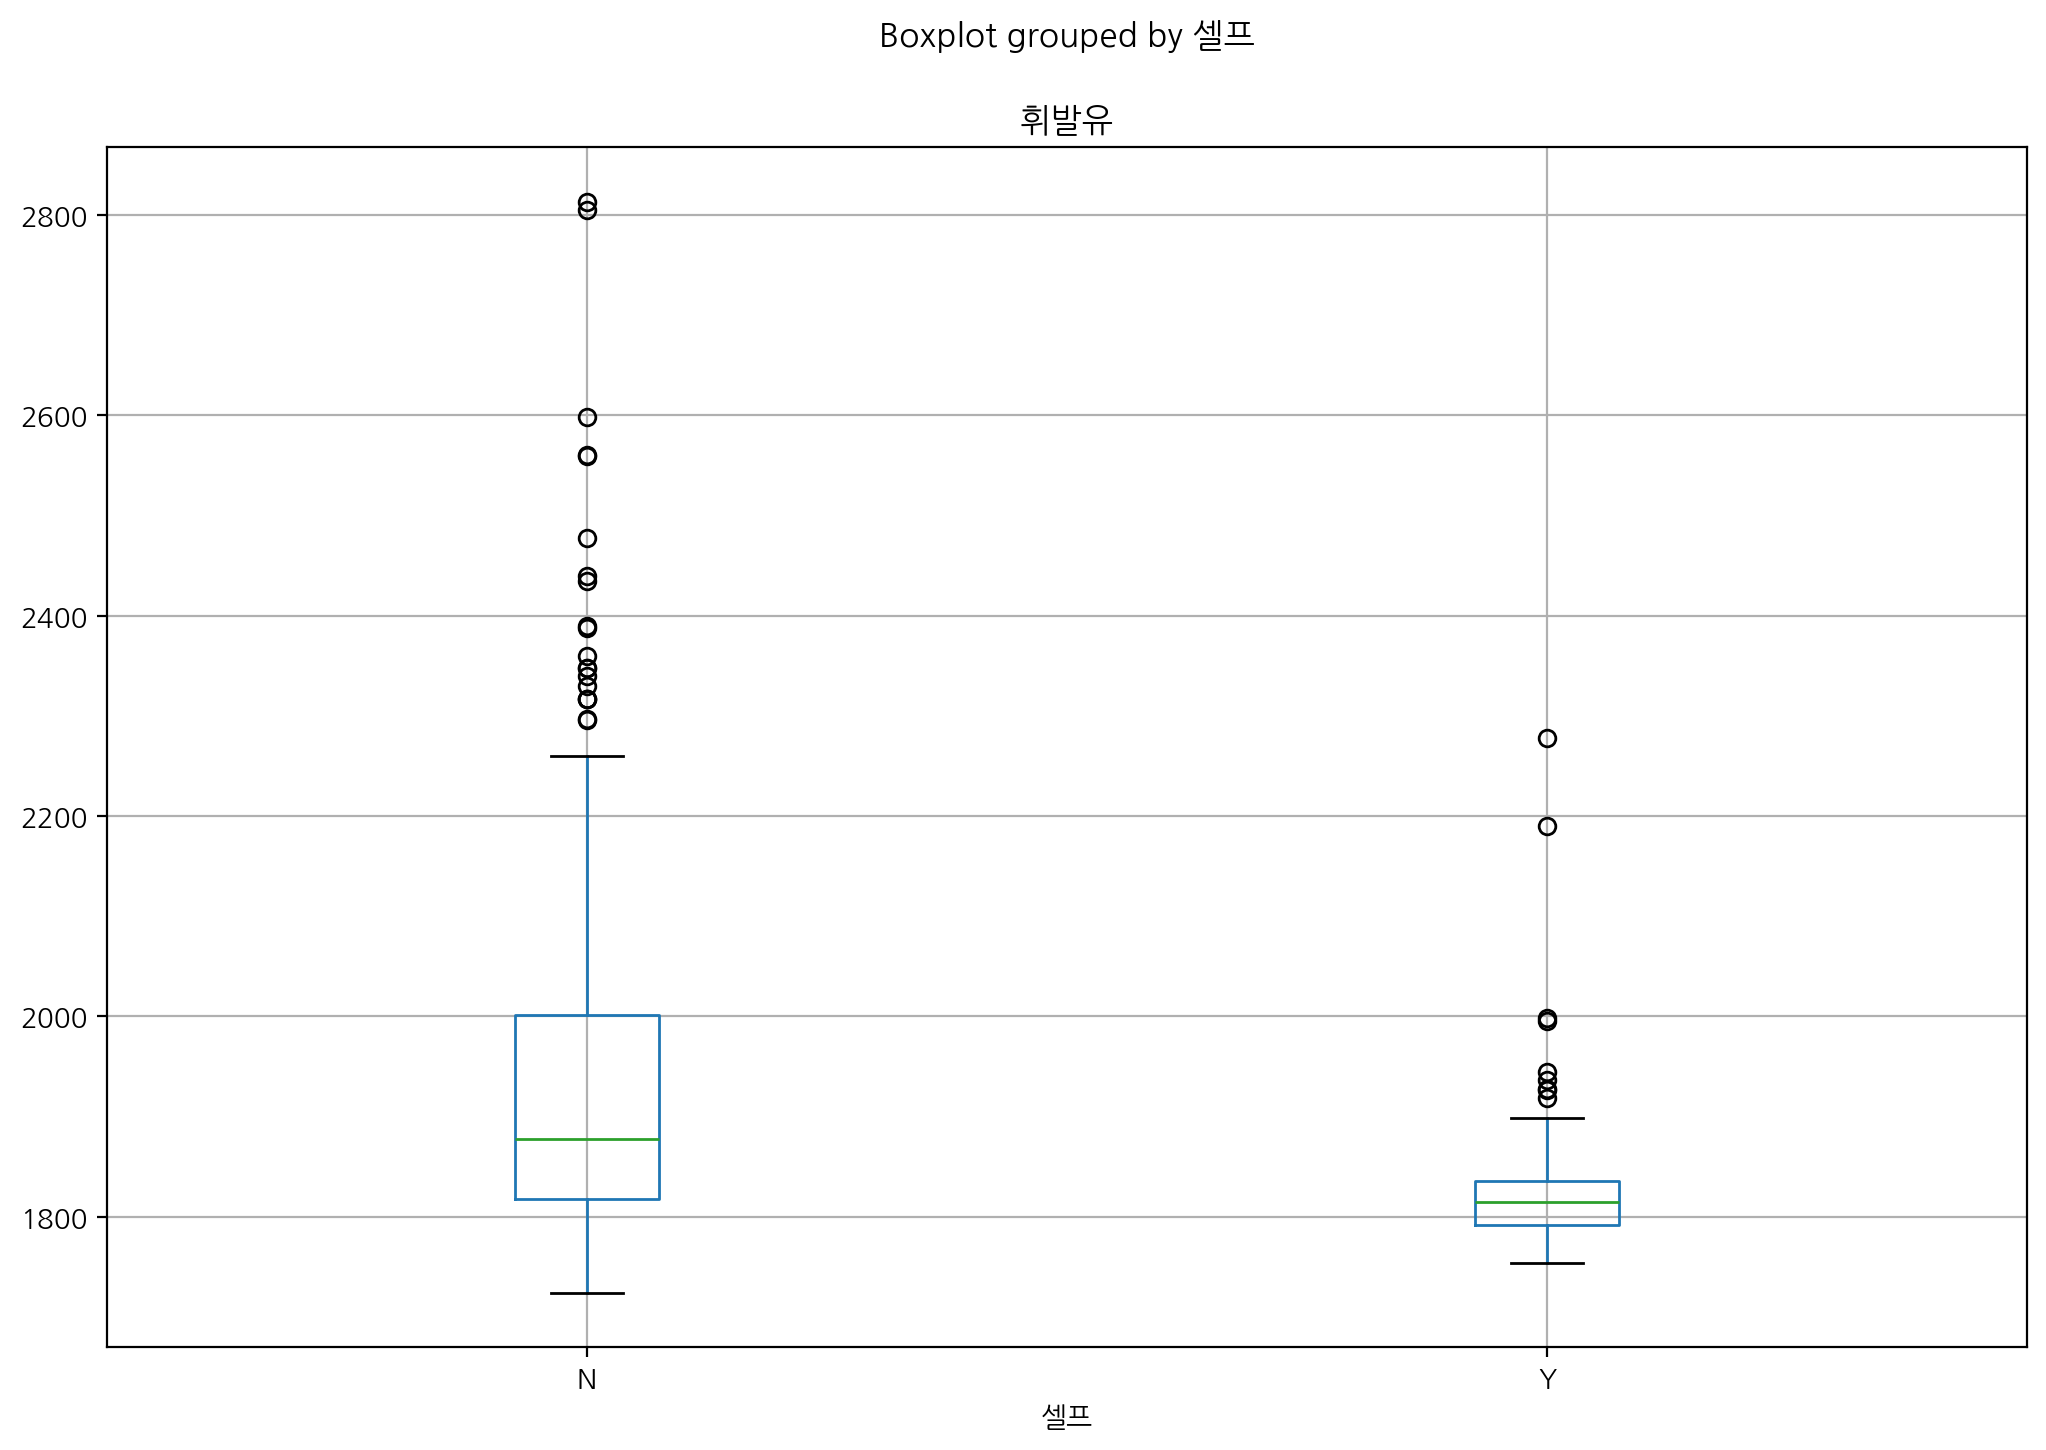

In [41]:
# Boxplot - Pandas
stations.boxplot(column='휘발유', by='셀프', figsize=(12, 8))
plt.show()

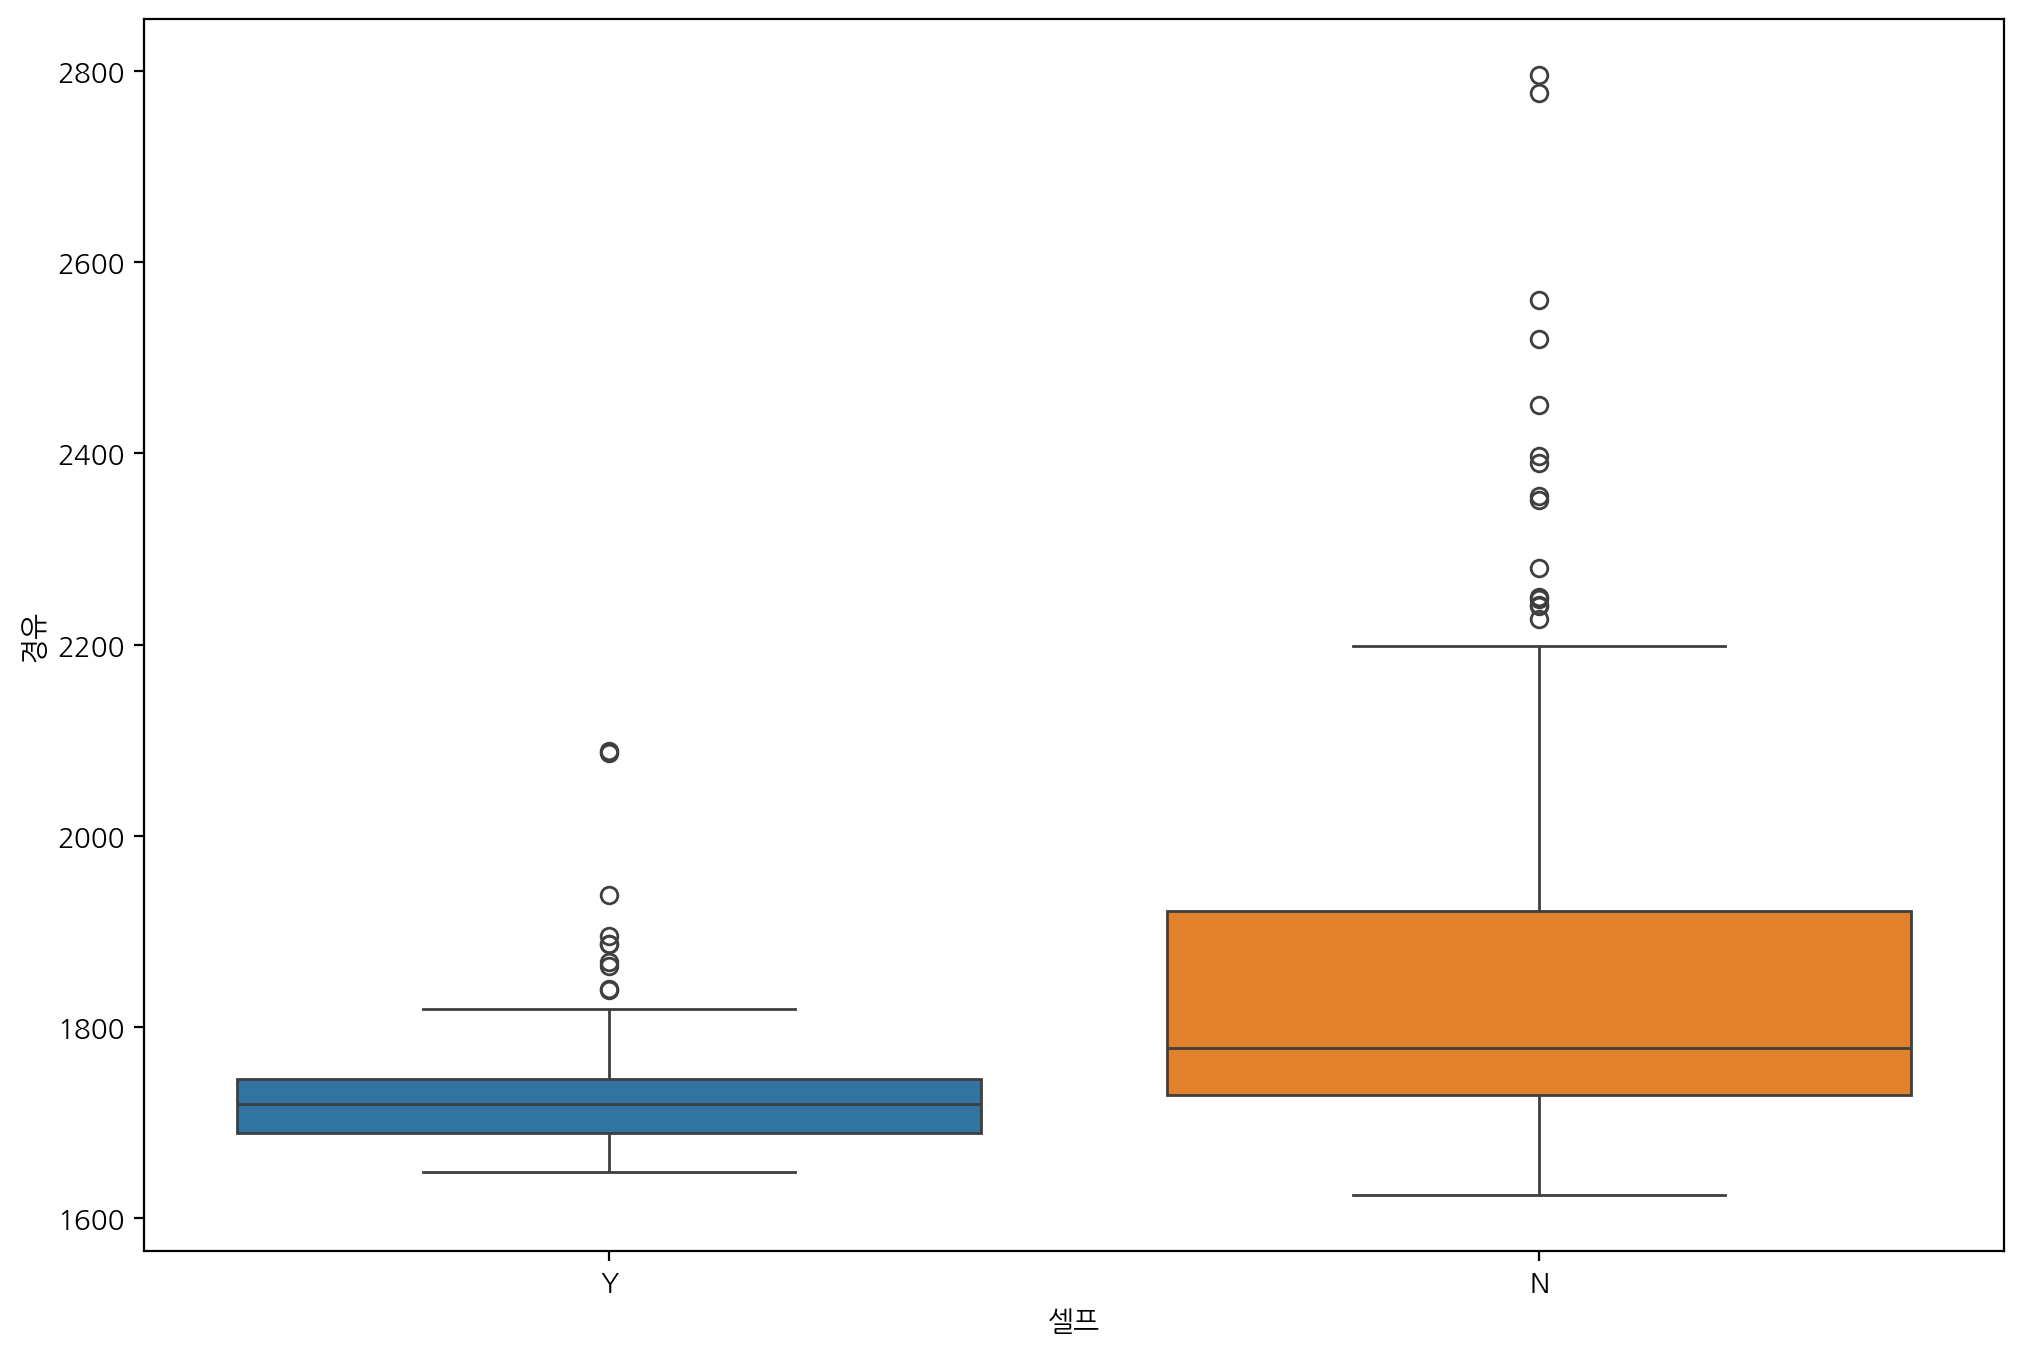

In [44]:
# Boxplot - seaborn
fig, ax = plt.subplots(figsize=(12, 8))
sns.boxplot(x='셀프', y='경유', hue='셀프', data=stations)
plt.show()

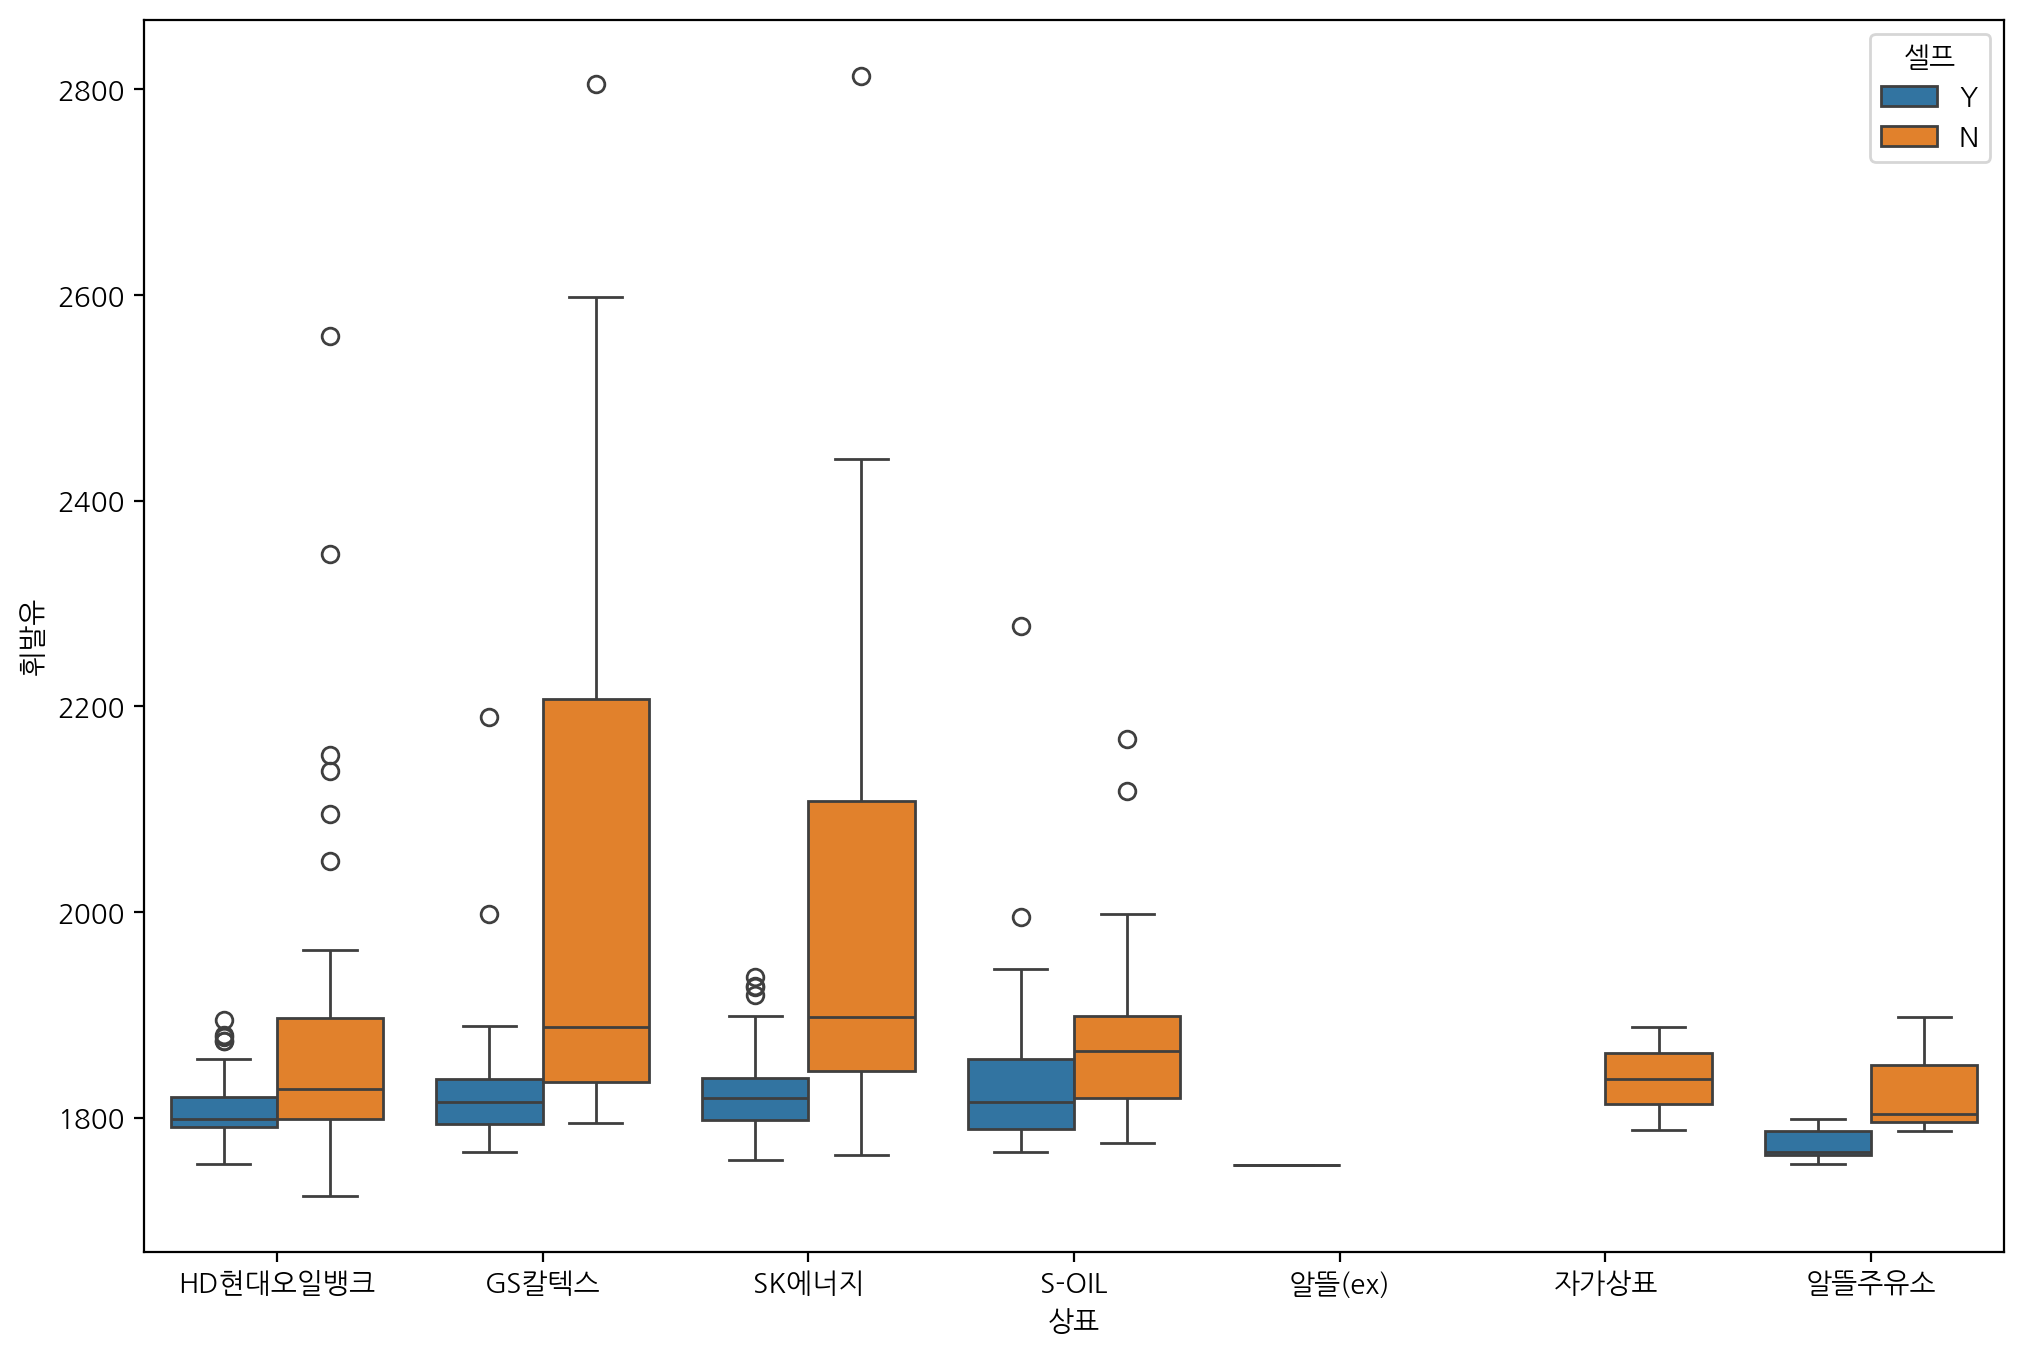

In [45]:
# Boxplot - seaborn
fig, ax = plt.subplots(figsize=(12, 8))
sns.boxplot(x='상표', y='휘발유', hue='셀프', data=stations)
plt.show()

### **5-3. 주유소 가격 지도 시각화**

In [46]:
import folium

In [50]:
folium_gu_data = stations.pivot_table(index='구', values='휘발유', aggfunc='mean')
folium_gu_data.head(10)

,휘발유
구,
강남구,2047.125000
강동구,1900.461538
강북구,1796.333333
강서구,1830.848485
관악구,1835.000000
광진구,1834.615385
구로구,1844.473684
금천구,1809.818182
노원구,1832.214286


In [52]:
# 휘발유 가격 데이터 기준 지도 시각화
my_map = folium.Map(location=[37.5502, 126.982], zoom_start=11)
geo_data = './Data/skorea_municipalities_geo_simple.json'

folium.Choropleth(
    geo_data=geo_data,
    data=folium_gu_data,
    columns=[folium_gu_data.index, '휘발유'],
    key_on='feature.id',
    # 꾸미는 옵션
    fill_color='PuRd',
    legend_name='구별 휘발유 평균 가격'
).add_to(my_map)

my_map

In [54]:
folium_gu_data = stations.pivot_table(index='구', values='경유', aggfunc='mean')

In [55]:
# 경유 가격 데이터 기준 지도 시각화
my_map = folium.Map(location=[37.5502, 126.982], zoom_start=11)
geo_data = './Data/skorea_municipalities_geo_simple.json'

folium.Choropleth(
    geo_data=geo_data,
    data=folium_gu_data,
    columns=[folium_gu_data.index, '경유'],
    key_on='feature.id',
    # 꾸미는 옵션
    fill_color='PuRd',
    legend_name='구별 경유 평균 가격'
).add_to(my_map)

my_map